# Exploration des données Adult
Ce notebook charge les fichiers `adult.data` et `adult.test`, les fusionne, sauvegarde le résultat en `.parquet` et propose des analyses descriptives et graphiques sur les colonnes numériques et catégorielles.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
import pyarrow as pa
import os

In [37]:
# Définir les chemins des fichiers
data_dir = os.path.join('..', 'adult')
file_data = os.path.join(data_dir, 'adult.data')
file_test = os.path.join(data_dir, 'adult.test')

# Colonnes selon la documentation UCI
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'class_label'
]

def load_adult_file(filepath, columns, skiprows=0):
    df = pd.read_csv(filepath, names=columns, skiprows=skiprows, na_values='?', skipinitialspace=True)
    # Nettoyage : retirer les lignes vides ou mal formées
    df = df.dropna(how='all')
    return df

# Charger les deux fichiers
df_data = load_adult_file(file_data, columns)
df_test = load_adult_file(file_test, columns, skiprows=1)  # la première ligne de test est un header

# Fusionner les deux DataFrames
df_all = pd.concat([df_data, df_test], ignore_index=True)


df_all.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,class_label
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
# Chercher les doublons (Est ce que c'est pertinent dans ce type de jeu de données où un doublon peux en vrai etre 2 personnes ?)
duplicates = df_all[df_all.duplicated()]
print(f"Nombre de doublons : {len(duplicates)}")
display(duplicates.head(10))

Nombre de doublons : 29


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,class_label
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
15059,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
17040,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
18555,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,NaN,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [39]:
# Supprimer les doublons (lignes identiques sur toutes les colonnes)
df_all = df_all.drop_duplicates()

In [40]:
# nettoyage des données
df_all = df_all.dropna(subset=['age'])  # sécurité : retirer les lignes sans age
# - on vire race et sex of course, education_num et relationship ... :
df_all = df_all.drop(columns=['race', 'sex', 'education_num', 'relationship', 'fnlwgt'], errors='ignore')
# Nettoyer les valeurs de class_label pour retirer le point final pour certaines données
df_all['class_label'] = df_all['class_label'].str.replace('.', '', regex=False).str.strip()

df_all.info()


<class 'pandas.core.frame.DataFrame'>
Index: 48813 entries, 0 to 48841
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48813 non-null  int64 
 1   workclass       46014 non-null  object
 2   education       48813 non-null  object
 3   marital_status  48813 non-null  object
 4   occupation      46004 non-null  object
 5   capital_gain    48813 non-null  int64 
 6   capital_loss    48813 non-null  int64 
 7   hours_per_week  48813 non-null  int64 
 8   native_country  47957 non-null  object
 9   class_label     48813 non-null  object
dtypes: int64(4), object(6)
memory usage: 4.1+ MB


In [ ]:
# Vérification que la cible est propre
nb_variante = df_all['class_label'].nunique()
print(f"Nombre de variantes dans 'class_label' : {df_all['class_label'].unique()}")

Nombre de variantes dans 'class_label' : ['<=50K' '>50K']


In [42]:
# Sélectionner les lignes où au moins une des trois colonnes est manquante
missing = df_all[df_all[['workclass', 'occupation', 'native_country']].isnull().any(axis=1)]

# Afficher les 10 premières lignes concernées
display(missing.head(10))

,age,workclass,education,marital_status,occupation,capital_gain,capital_loss,hours_per_week,native_country,class_label
14,40,Private,Assoc-voc,Married-civ-spouse,Craft-repair,0,0,40,NaN,>50K
27,54,NaN,Some-college,Married-civ-spouse,NaN,0,0,60,South,>50K
38,31,Private,Some-college,Married-civ-spouse,Sales,0,0,38,NaN,>50K
51,18,Private,HS-grad,Never-married,Other-service,0,0,30,NaN,<=50K
61,32,NaN,7th-8th,Married-spouse-absent,NaN,0,0,40,NaN,<=50K
69,25,NaN,Some-college,Never-married,NaN,0,0,40,United-States,<=50K
77,67,NaN,10th,Married-civ-spouse,NaN,0,0,2,United-States,<=50K
93,30,Private,HS-grad,Married-civ-spouse,Sales,0,1573,35,NaN,<=50K
106,17,NaN,10th,Never-married,NaN,34095,0,32,United-States,<=50K
128,35,NaN,HS-grad,Married-civ-spouse,NaN,0,0,40,United-States,<=50K


In [43]:
# Supprimer les lignes où 'workclass' ou 'occupation' ne sont pas remplis
df_all = df_all.dropna(subset=['workclass', 'occupation'])

# Pour les valeurs manquantes restantes dans 'native_country', on attribue 'United-States'
df_all['native_country'] = df_all['native_country'].fillna('United-States')

# Vérification rapide
print("Valeurs manquantes restantes par colonne :")
print(df_all.isnull().sum())

Valeurs manquantes restantes par colonne :
age               0
workclass         0
education         0
marital_status    0
occupation        0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
class_label       0
dtype: int64


In [45]:
# DONNEES PROPRES ! Aperçu des données fusionnées
print('Aperçu des premières lignes :')
display(df_all.head())
print('\nInformations générales :')
df_all.info()

Aperçu des premières lignes :


,age,workclass,education,marital_status,occupation,capital_gain,capital_loss,hours_per_week,native_country,class_label
0,39,State-gov,Bachelors,Never-married,Adm-clerical,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,0,0,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,0,0,40,Cuba,<=50K



Informations générales :
<class 'pandas.core.frame.DataFrame'>
Index: 46004 entries, 0 to 48841
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             46004 non-null  int64 
 1   workclass       46004 non-null  object
 2   education       46004 non-null  object
 3   marital_status  46004 non-null  object
 4   occupation      46004 non-null  object
 5   capital_gain    46004 non-null  int64 
 6   capital_loss    46004 non-null  int64 
 7   hours_per_week  46004 non-null  int64 
 8   native_country  46004 non-null  object
 9   class_label     46004 non-null  object
dtypes: int64(4), object(6)
memory usage: 3.9+ MB


In [46]:
# Enregistrer le DataFrame fusionné au format .parquet
parquet_path = os.path.join(os.getcwd(), 'adult_all.parquet')
df_all.to_parquet(parquet_path, engine='pyarrow')
print(f"Fichier .parquet enregistré : {parquet_path}")

Fichier .parquet enregistré : e:\01_WORKS\00_wip\7SHAPES\simplon\mod6_1\database\notebooks\adult_all.parquet


In [26]:
# Statistiques descriptives des colonnes numériques
df_all.describe()

,age,capital_gain,capital_loss,hours_per_week
count,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1079.067626,87.502314,40.422382
std,13.710510,7452.019058,403.004552,12.391444
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


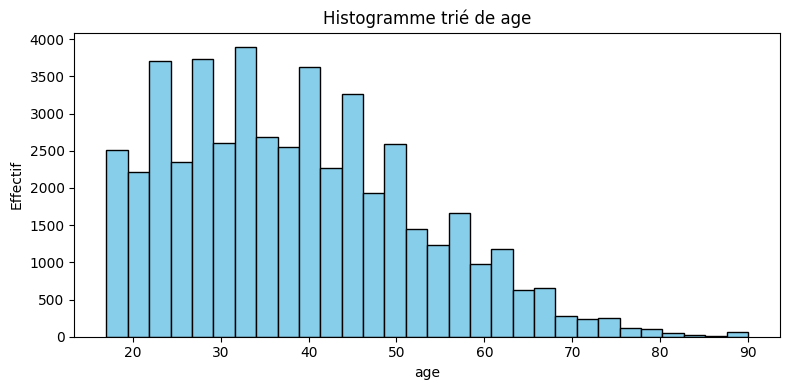

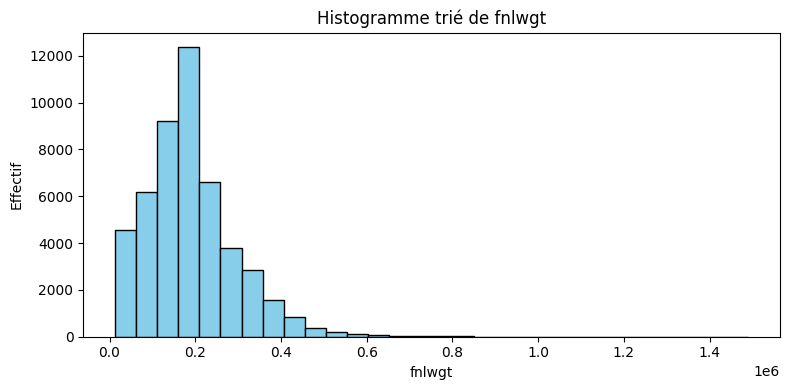

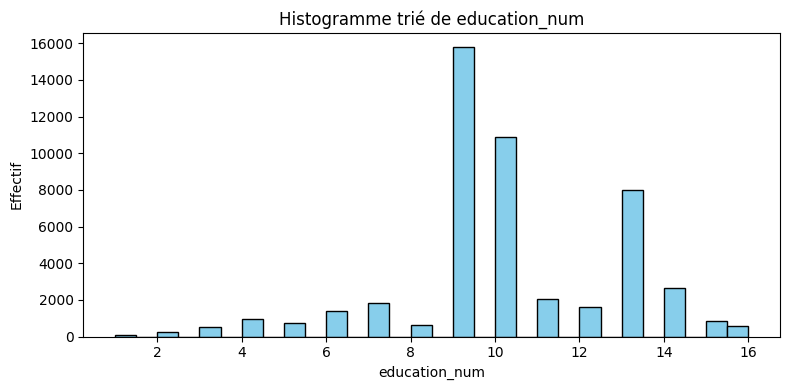

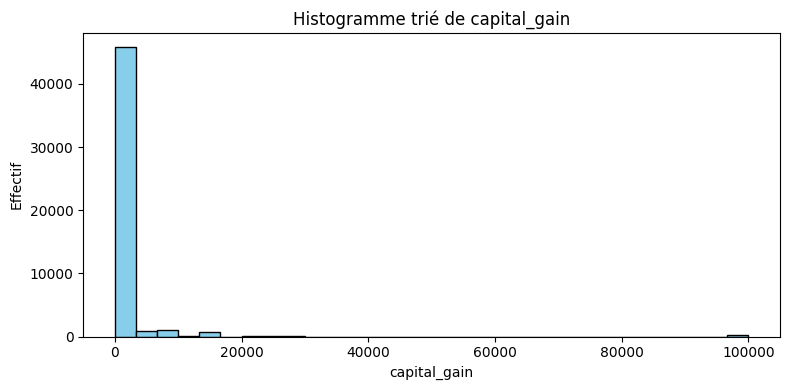

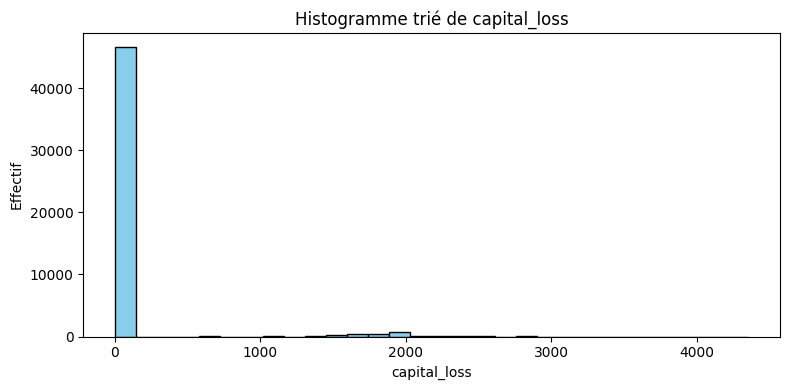

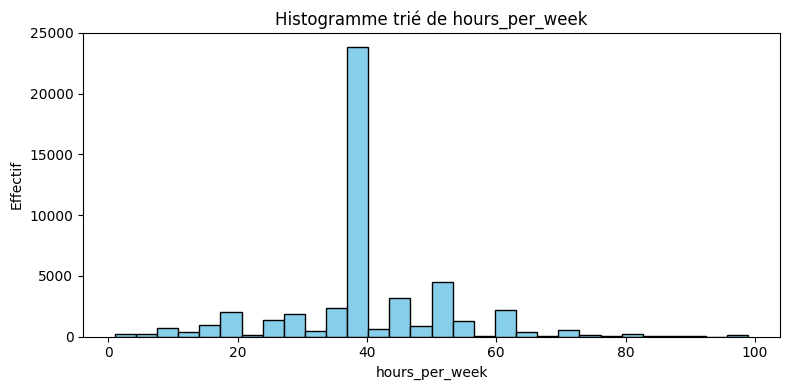

In [7]:
# Visualisation : histogrammes triés pour chaque colonne numérique
num_cols = df_all.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sorted_vals = df_all[col].dropna().sort_values()
    plt.hist(sorted_vals, bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogramme trié de {col}')
    plt.xlabel(col)
    plt.ylabel('Effectif')
    plt.tight_layout()
    plt.show()

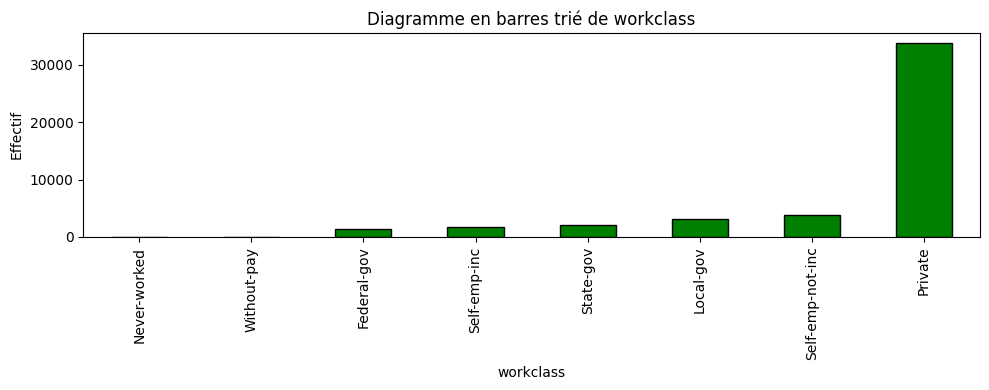

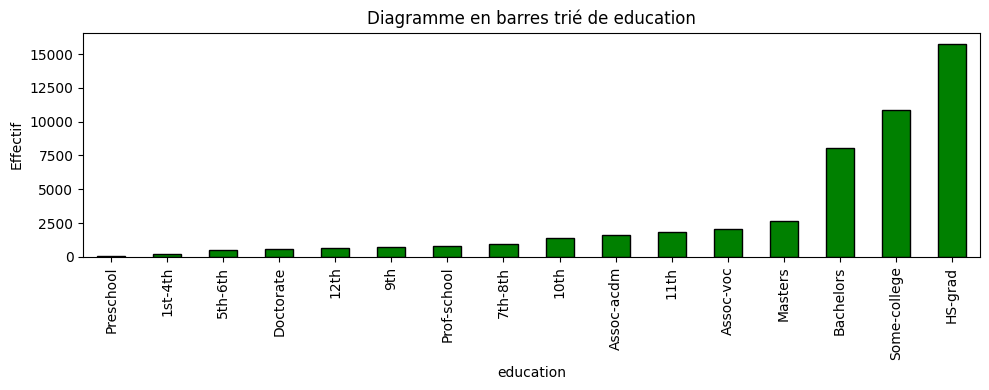

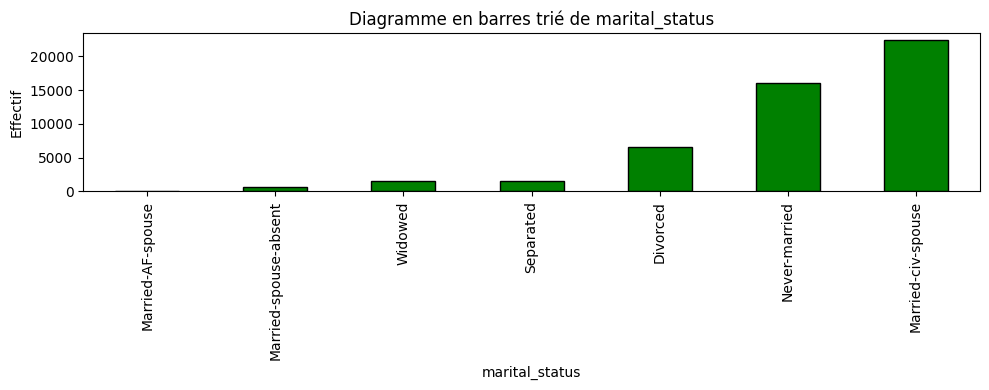

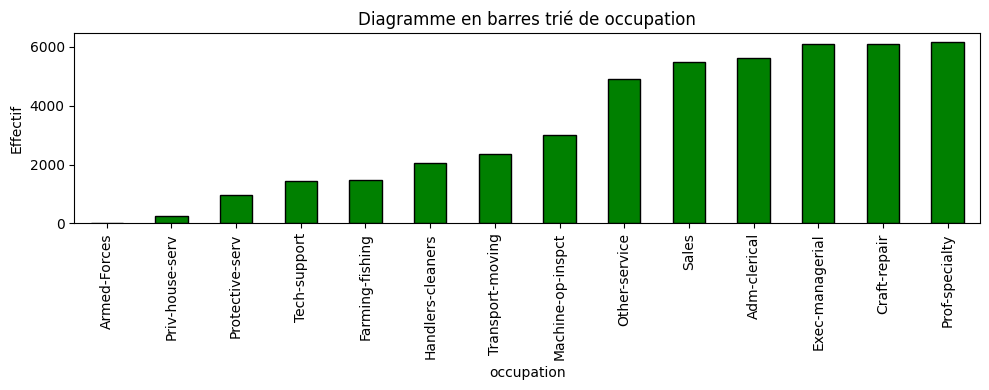

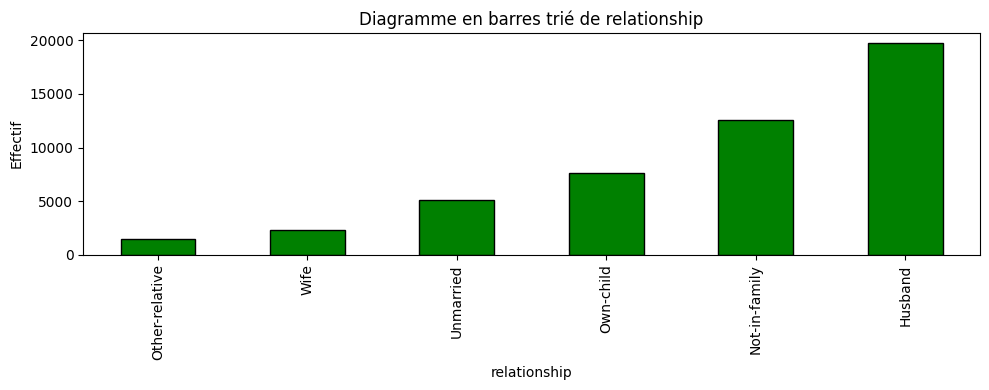

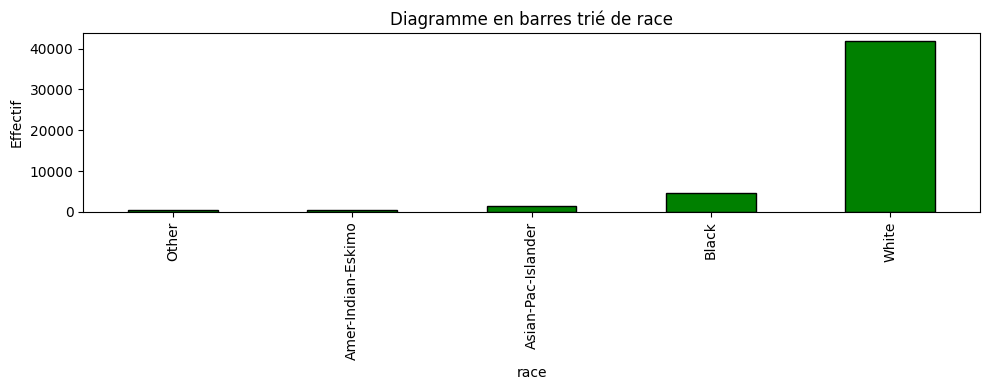

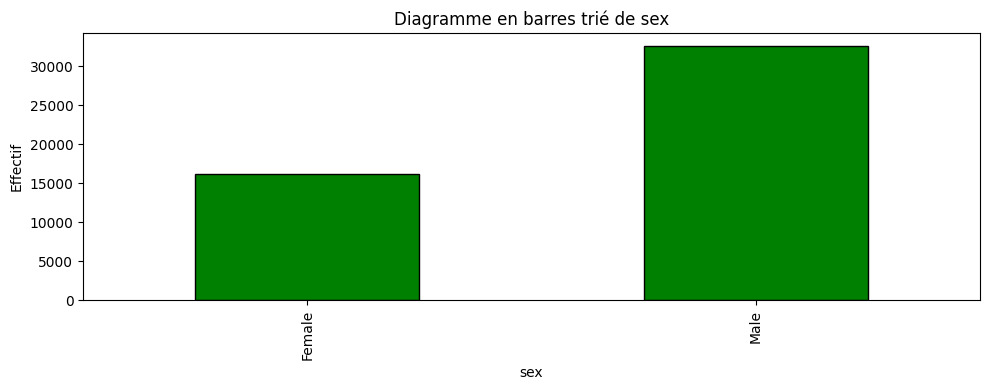

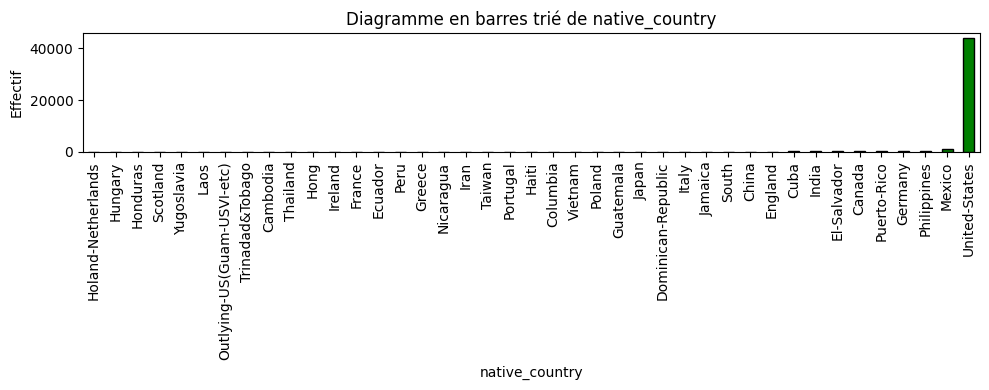

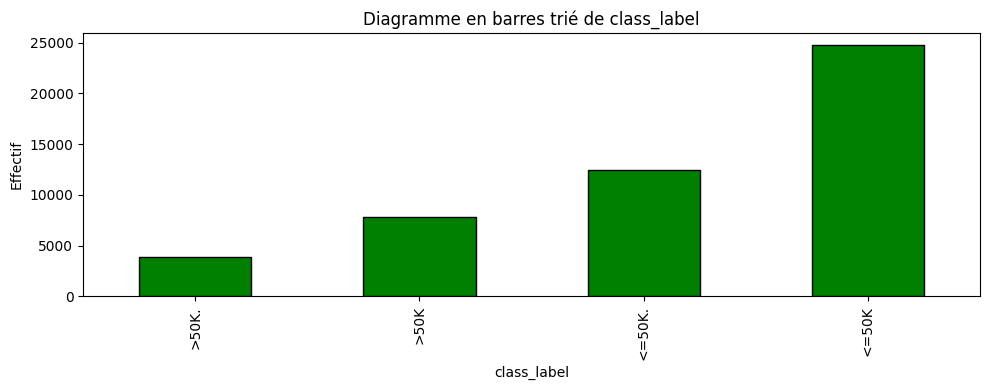

In [ ]:
# Visualisation : diagrammes en barres pour chaque colonne catégorielle
cat_cols = df_all.select_dtypes(include=['object']).columns
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    value_counts = df_all[col].value_counts().sort_values()
    value_counts.plot(kind='bar', color='green', edgecolor='black')
    plt.title(f'Diagramme en barres trié de {col}')
    plt.xlabel(col)
    plt.ylabel('Effectif')
    plt.tight_layout()
    plt.show()

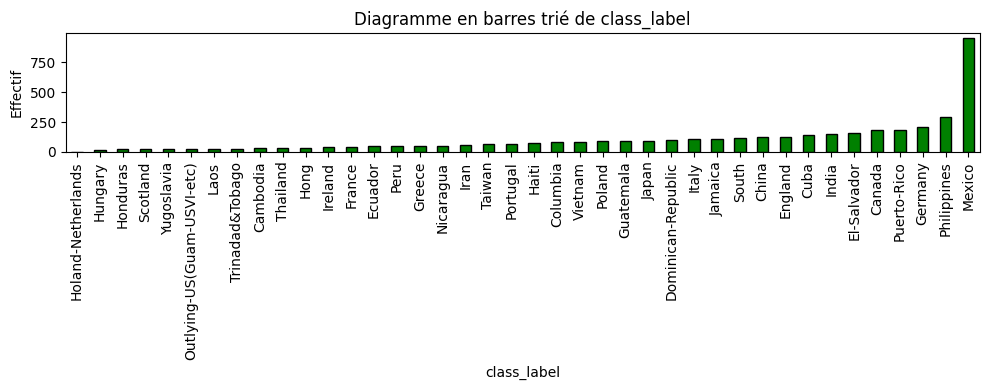

In [ ]:
df_allv2 = df_all[df_all["native_country"] != "United-States"]
plt.figure(figsize=(10, 4))
value_counts = df_allv2["native_country"].value_counts().sort_values()
value_counts.plot(kind='bar', color='green', edgecolor='black')
plt.title(f'Diagramme en barres trié de native_country')
plt.xlabel(col)
plt.ylabel('Effectif')
plt.tight_layout()
plt.show()

In [ ]:

df_allv2["native_country"].value_counts().sum()

np.int64(4153)

In [21]:
# nettoyage des données
# on vire education_num et relationship :
df_all = df_all.drop(columns=['race', 'sex', 'education_num', 'relationship', 'fnlwgt'], errors='ignore')
df_all.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   education       48842 non-null  object
 3   marital_status  48842 non-null  object
 4   occupation      46033 non-null  object
 5   capital_gain    48842 non-null  int64 
 6   capital_loss    48842 non-null  int64 
 7   hours_per_week  48842 non-null  int64 
 8   native_country  47985 non-null  object
 9   class_label     48842 non-null  object
dtypes: int64(4), object(6)
memory usage: 3.7+ MB


In [24]:
df_all_tmp = df_all[df_all["workclass"] == None]
df_all_tmp.head()

,age,workclass,education,marital_status,occupation,capital_gain,capital_loss,hours_per_week,native_country,class_label


In [25]:
missing_entries = df_all[df_all.isnull().any(axis=1)]
print(f"Nombre de lignes avec au moins une valeur manquante : {len(missing_entries)}")
display(missing_entries)

Nombre de lignes avec au moins une valeur manquante : 3620


,age,workclass,education,marital_status,occupation,capital_gain,capital_loss,hours_per_week,native_country,class_label
14,40,Private,Assoc-voc,Married-civ-spouse,Craft-repair,0,0,40,NaN,>50K
27,54,NaN,Some-college,Married-civ-spouse,NaN,0,0,60,South,>50K
38,31,Private,Some-college,Married-civ-spouse,Sales,0,0,38,NaN,>50K
51,18,Private,HS-grad,Never-married,Other-service,0,0,30,NaN,<=50K
61,32,NaN,7th-8th,Married-spouse-absent,NaN,0,0,40,NaN,<=50K
...,...,...,...,...,...,...,...,...,...,...
48769,21,NaN,Some-college,Never-married,NaN,0,0,30,United-States,<=50K.
48800,73,NaN,HS-grad,Married-civ-spouse,NaN,0,0,25,Canada,<=50K.
48812,81,NaN,Assoc-voc,Married-civ-spouse,NaN,2936,0,20,United-States,<=50K.
48826,50,Local-gov,Masters,Married-civ-spouse,Prof-specialty,0,0,40,NaN,>50K.


In [13]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   marital_status  48842 non-null  object
 5   occupation      46033 non-null  object
 6   race            48842 non-null  object
 7   sex             48842 non-null  object
 8   capital_gain    48842 non-null  int64 
 9   capital_loss    48842 non-null  int64 
 10  hours_per_week  48842 non-null  int64 
 11  native_country  47985 non-null  object
 12  class_label     48842 non-null  object
dtypes: int64(5), object(8)
memory usage: 4.8+ MB


In [ ]:
# corriger class label
df_all['class_label'] = df_all['class_label'].str.strip() 